In [185]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [186]:
data_logical_filter = pd.read_csv("data/dataset_logical_filter.csv")
data_price_ratio = pd.read_csv("data/dataset_Price_Ratio_.20.csv")
dfLogical = pd.DataFrame(data_logical_filter)
dfPrice = pd.DataFrame(data_price_ratio)
dfLogical

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
293,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
294,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
295,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
296,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [187]:
###### Convert categorical text columns into numbers for model training

In [188]:
dfLogical['Fuel_Type'] = dfLogical['Fuel_Type'].map({'Petrol': 0, 'Diesel': 1})
dfLogical['Seller_Type'] = dfLogical['Seller_Type'].map({'Dealer': 0, 'Individual': 1})
dfLogical['Transmission'] = dfLogical['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfLogical.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,1,0,0,0
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,1,0,0,0


In [189]:
def train_linear_model(dataframe, target_column):
    X = dataframe.drop(target_column, axis=1)
    y = dataframe[target_column].values.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model, X_test, y_test

In [190]:
model_logical, X_test_logical, y_test_logical = train_linear_model(dfLogical, 'Selling_Price')

In [191]:
y_pred_logical = model_logical.predict(X_test_logical)

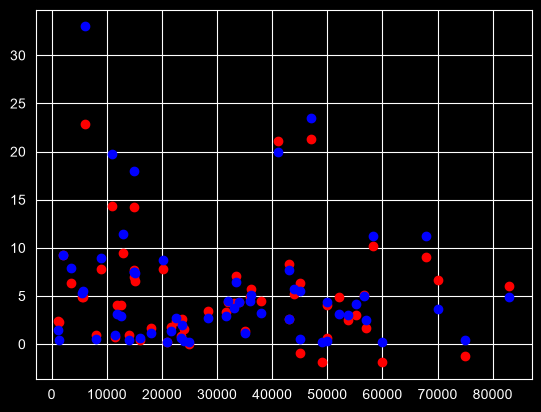

In [192]:
plt.scatter(X_test_logical.Kms_Driven, y_pred_logical, color='red')
plt.scatter(X_test_logical.Kms_Driven, y_test_logical, color='blue')

In [193]:
#######errore and score Logical model

In [194]:
mae = mean_absolute_error(y_test_logical, y_pred_logical)
mse = mean_squared_error(y_test_logical, y_pred_logical)
r2 = r2_score(y_test_logical, y_pred_logical)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.9087069580726951
MAE: 1.1204433095774395
MSE: 3.557146597053331


In [195]:
dfPrice = pd.get_dummies(dfPrice, columns=['Fuel_Type', 'Seller_Type'], drop_first=True, dtype=int)

dfPrice['Transmission'] = dfPrice['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfPrice.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual
0,2014,3.35,5.59,27000,0,0,1,0
1,2013,4.75,9.54,43000,0,0,0,0
2,2017,7.25,9.85,6900,0,0,1,0
3,2011,2.85,4.15,5200,0,0,1,0
4,2014,4.60,6.87,42450,0,0,0,0


In [196]:
model_price, X_test_price, y_test_price = train_linear_model(dfPrice, 'Selling_Price')
y_pred_price = model_price.predict(X_test_price)


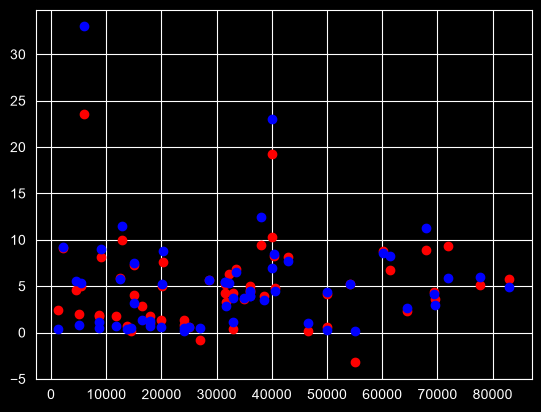

In [197]:
plt.scatter(X_test_price.Kms_Driven, y_pred_price, color='red')
plt.scatter(X_test_price.Kms_Driven, y_test_price, color='blue')

In [198]:
mae = mean_absolute_error(y_test_price, y_pred_price)
mse = mean_squared_error(y_test_price, y_pred_price)
r2 = r2_score(y_test_price, y_pred_price)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.8947321978390635
MAE: 1.0375201411299693
MSE: 3.1012508523349904


I choose model_price, because i think its more accurate than model_logical. now i gonna train model more accurate base on effect of feature

In [199]:
def train_linear_model_X_y(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model, X_test, y_test

In [200]:
dfPrice['log_Selling_Price'] = np.log(dfPrice['Selling_Price'])
dfPrice

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual,log_Selling_Price
0,2014,3.35,5.59,27000,0,0,1,0,1.208960
1,2013,4.75,9.54,43000,0,0,0,0,1.558145
2,2017,7.25,9.85,6900,0,0,1,0,1.981001
3,2011,2.85,4.15,5200,0,0,1,0,1.047319
4,2014,4.60,6.87,42450,0,0,0,0,1.526056
...,...,...,...,...,...,...,...,...,...
289,2016,9.50,11.60,33988,0,0,0,0,2.251292
290,2015,4.00,5.90,60000,0,0,1,0,1.386294
291,2009,3.35,11.00,87934,0,0,1,0,1.208960
292,2017,11.50,12.50,9000,0,0,0,0,2.442347


In [201]:
X_exp = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y_exp = dfPrice['log_Selling_Price'].values.reshape(-1, 1)

In [202]:
model_exp, X_test_exp, y_test_log = train_linear_model_X_y(X_exp, y_exp)
y_pred_log = model_exp.predict(X_test_exp)

In [203]:
y_pred_log_real = np.exp(y_pred_log)
y_test_log_real = np.exp(y_test_log)

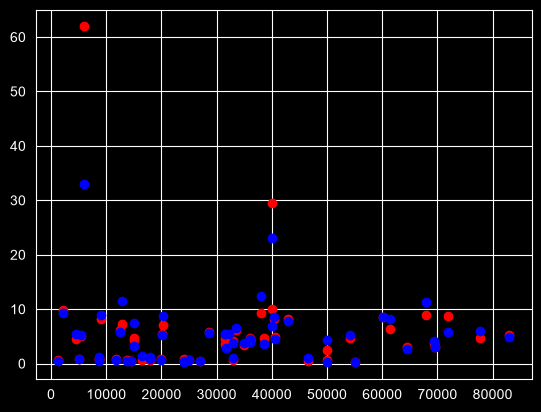

In [204]:
plt.scatter(X_test_exp.Kms_Driven, y_pred_log_real, color='red')
plt.scatter(X_test_exp.Kms_Driven, y_test_log_real, color='blue')

In [205]:
r2 = r2_score(y_test_log_real, y_pred_log_real)
mae = mean_absolute_error(y_test_log_real, y_pred_log_real)
mse = mean_squared_error(y_test_log_real, y_pred_log_real)
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.44425610008058747
MAE: 1.3581233436167772
MSE: 16.37253944629823


using cross validation for gain more score

In [206]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [207]:
dfPrice

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Petrol,Seller_Type_Individual,log_Selling_Price
0,2014,3.35,5.59,27000,0,0,1,0,1.208960
1,2013,4.75,9.54,43000,0,0,0,0,1.558145
2,2017,7.25,9.85,6900,0,0,1,0,1.981001
3,2011,2.85,4.15,5200,0,0,1,0,1.047319
4,2014,4.60,6.87,42450,0,0,0,0,1.526056
...,...,...,...,...,...,...,...,...,...
289,2016,9.50,11.60,33988,0,0,0,0,2.251292
290,2015,4.00,5.90,60000,0,0,1,0,1.386294
291,2009,3.35,11.00,87934,0,0,1,0,1.208960
292,2017,11.50,12.50,9000,0,0,0,0,2.442347


In [208]:
X_Kfold_dfPrice = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y_Kfold_dfPrice = dfPrice['Selling_Price'].values.reshape(-1, 1)

In [209]:
KFold_model = LinearRegression()

In [210]:
kfold_validation = KFold (5)

In [211]:
result = cross_val_score(KFold_model, X_Kfold_dfPrice, y_Kfold_dfPrice, cv=kfold_validation)


In [212]:
print(result)
print(np.mean(result))

[   0.90561135    0.86208904 -102.07104805    0.80515221    0.88539946]
-19.722559197347312


In [213]:
dfLogical

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,0,0,0,0
1,2013,4.75,9.54,43000,1,0,0,0
2,2017,7.25,9.85,6900,0,0,0,0
3,2011,2.85,4.15,5200,0,0,0,0
4,2014,4.60,6.87,42450,1,0,0,0
...,...,...,...,...,...,...,...,...
293,2016,9.50,11.60,33988,1,0,0,0
294,2015,4.00,5.90,60000,0,0,0,0
295,2009,3.35,11.00,87934,0,0,0,0
296,2017,11.50,12.50,9000,1,0,0,0


In [214]:
X_Kfold_dfLog = dfLogical.drop('Selling_Price', axis=1)
y_Kfold_dfLog = dfLogical['Selling_Price'].values.reshape(-1, 1)

In [215]:
result = cross_val_score(KFold_model, X_Kfold_dfLog, y_Kfold_dfLog, cv=kfold_validation)
print(result)
print(np.mean(result))

[  0.88909206   0.83528096 -85.99224375   0.78852776   0.87064299]
-16.521739994232842


find rows that leading to bad score

In [216]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
fold_number = 1

In [217]:
X = dfPrice.drop(['Selling_Price', 'log_Selling_Price'], axis=1)
y = dfPrice['Selling_Price']

In [218]:
total_score = 0
for train_index, test_index in kf.split(X):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    if score < 0:
        print("warning", fold_number, score)
        errors = abs(y_test-y_pred)

        bad_cars = X_test.copy()
        bad_cars['Actual_Price'] = y_test
        bad_cars['Predicted_Price'] = y_pred
        bad_cars['Error'] = errors

        bad_cars = bad_cars.sort_values(by='Error', ascending=False)
        display(bad_cars.head(5))
        break
    total_score = total_score + score
    print(score)
    fold_number =+ 1
total_score / kf.n_splits

0.8255851589422543
0.8476877443955985
0.9317739654229373
0.9250025441823533
0.9155537400915366


0.889120630606936

In [219]:
#we dont have outlier data

In [220]:
#calculate correlations

In [221]:
terget_feature = dfPrice['Selling_Price']

for col_name in dfPrice.columns:
    if col_name != 'Selling_Price':
        x = dfPrice[col_name]
        matrix = np.corrcoef(x, terget_feature)
        corr_value = matrix[0, 1]
        print(f"{col_name}: {corr_value}")

Year: 0.2645329196882599
Present_Price: 0.9063750765223179
Kms_Driven: 0.10179165844200844
Transmission: 0.43763854864135127
Owner: -0.10389364705102506
Fuel_Type_Petrol: -0.5472913529122331
Seller_Type_Individual: -0.5701290436485259
log_Selling_Price: 0.8132777708387869


In [222]:
print(model_price.coef_)
print(model_price.intercept_)

[[ 3.41111920e-01  5.43033235e-01 -1.92182903e-05  5.64357248e-01
   6.86933878e-01 -1.21549472e+00 -6.61290327e-01]]
[-684.53276886]


In [223]:
#for having better experience, continue the new model in the model_V2 file